In [ ]:
import os
import glob
import time
import math

import numpy as np
import uproot
import matplotlib.pyplot as plt
import ROOT
from ROOT import RooFit as RF
from ROOT import (
    kBlue, kRed, kViolet, kMagenta, kOrange, kGreen, kBlack,
    kAzure, kFullCircle, kDashed, kDotted, kDashDotted
)
from IPython.display import Image as IPyImage, display as ipydisplay

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)
ROOT.EnableImplicitMT()

# Custom HILL/HORNS PDFs, compiled standalone against this ROOT build.
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

# RooJohnsonSU is built separately; take the most recent build in the directory.
JOHNSON_LIB_DIR = os.path.expandvars("$HOME/RooJohnsonBuild")
ROOT.gSystem.AddDynamicPath(JOHNSON_LIB_DIR)
libs = sorted(glob.glob(os.path.join(JOHNSON_LIB_DIR, "libRooJohnsonSU_*.so")))
if not libs:
    raise RuntimeError(f"No RooJohnsonSU build found in {JOHNSON_LIB_DIR}")
ret = ROOT.gSystem.Load(libs[-1])
print(f"[ROOT] Loaded JohnsonSU: {libs[-1]} (ret={ret})")
print("[ROOT] Has RooJohnsonSU:", hasattr(ROOT, "RooJohnsonSU"))
if not hasattr(ROOT, "RooJohnsonSU"):
    raise RuntimeError("RooJohnsonSU failed to register with ROOT")

def get_class(name_candidates):
    for n in name_candidates:
        cls = getattr(ROOT, n, None)
        if cls is not None:
            return cls, n
    return None, None

def require_pdf_class(name_candidates, help_msg):
    cls, used = get_class(name_candidates)
    if cls is None:
        raise RuntimeError(f"{help_msg} Missing: {name_candidates}")
    return cls, used

def make_pull_frame(frame):
    hpull = frame.pullHist("data", "model", True)
    hpull.SetMarkerStyle(20)
    hpull.SetMarkerSize(0.6)
    pf = m.frame()
    pf.addPlotable(hpull, "P")
    pf.SetYTitle("Pull")
    pf.SetMinimum(-4)
    pf.SetMaximum(4)
    return pf

def make_legend():
    mk = ROOT.TMarker(0, 0, 20); mk.SetMarkerSize(1.0)
    l_tot = ROOT.TLine(0, 0, 1, 0); l_tot.SetLineColor(COL_TOT); l_tot.SetLineWidth(3)
    l_sig = ROOT.TLine(0, 0, 1, 0); l_sig.SetLineColor(COL_SIG); l_sig.SetLineStyle(ROOT.kDashed); l_sig.SetLineWidth(3)
    b_comb = ROOT.TBox(0, 0, 1, 1); b_comb.SetFillColor(COL_COMB); b_comb.SetFillStyle(1001)
    b_part = ROOT.TBox(0, 0, 1, 1); b_part.SetFillColor(COL_PART); b_part.SetFillStyle(1001)

    leg = ROOT.TLegend(0.12, 0.62, 0.46, 0.88)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextSize(0.035)
    leg.AddEntry(mk, "Data", "p")
    leg.AddEntry(l_tot, "Total fit", "l")
    leg.AddEntry(l_sig, "Signal (Johnson SU)", "l")
    leg.AddEntry(b_comb, "Combinatorial", "f")
    leg.AddEntry(b_part, "PartReco (merged)", "f")

    KEEP.extend([mk, l_tot, l_sig, b_comb, b_part, leg])
    return leg

def make_yield_box():
    pave = ROOT.TPaveText(0.62, 0.62, 0.88, 0.88, "NDC")
    pave.SetFillStyle(0); pave.SetBorderSize(0)
    pave.SetTextAlign(12); pave.SetTextSize(0.035)
    pave.AddText("Fitted yields:")
    pave.AddText(f"N_{{sig}}  = {Nsig.getVal():.0f} #pm {Nsig.getError():.0f}")
    pave.AddText(f"N_{{comb}} = {Ncomb.getVal():.0f} #pm {Ncomb.getError():.0f}")
    pave.AddText(f"N_{{part}} = {Npart.getVal():.0f} #pm {Npart.getError():.0f}")
    KEEP.append(pave)
    return pave

def build_column(col_idx, title, logy):
    cmain.cd(col_idx)
    pad_top = ROOT.TPad(f"pad_top_{col_idx}", f"pad_top_{col_idx}", 0.0, 0.30, 1.0, 1.0)
    pad_bot = ROOT.TPad(f"pad_bot_{col_idx}", f"pad_bot_{col_idx}", 0.0, 0.00, 1.0, 0.30)
    pad_top.SetBottomMargin(0.02)
    pad_bot.SetTopMargin(0.05)
    pad_bot.SetBottomMargin(0.30)
    pad_top.Draw(); pad_bot.Draw()
    KEEP.extend([pad_top, pad_bot])

    pad_top.cd()
    if logy: pad_top.SetLogy(True)
    fr = draw_frame(title, logy=logy)
    fr.Draw(); KEEP.append(fr)
    make_legend().Draw()
    make_yield_box().Draw()

    pad_bot.cd()
    pull = make_pull_frame(fr)
    pull.Draw(); KEEP.append(pull)

In [3]:
TREE_PATH = "Tuple/DecayTree"

DPI_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_down_final_block7.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_up_final_block8.root",
]
DK_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

LB_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]

assert all(os.path.exists(f) for f in DPI_FILES + DK_FILES + LB_FILES), "Missing input ROOT files."

NBINS = 300
mmin, mmax = 4950.0, 6000.0  # MeV

D_MASS   = 1869.65
D_WINDOW = 20.0

B_END_VCHI2DOF_MAX = 10.0
D_END_VCHI2DOF_MAX = 10.0

BACHELOR_PIDK_MAX = 0
BACHELOR_PIDK_MIN = 5

B_FDCHI2_MIN = 70.0
B_IPCHI2_MAX = 15.0
B_DIRA_MIN   = 0.9995
MVA_BRANCH   = "lab0_MVA"
MVA_CUT      = 0.9

COMMON_BRANCHES = [
    "lab0_MASS",
    "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF",
    "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2",
    "lab0_BPVDIRA",
    MVA_BRANCH,
]

# tqdm optional
def build_vals(files, mode="Dpi"):
    assert mode in ("Dpi", "DK")
    vals_all = []
    print(f"\n[build {mode}] applying common Bd selection + PID_{mode}...")
    for arrays in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=COMMON_BRANCHES,
                       step_size="60 MB",
                       library="np", allow_missing=False),
        desc=f"Reading {mode} tuples"
    ):
        mB     = arrays["lab0_MASS"]
        bchi   = arrays["lab0_END_VCHI2DOF"]
        dchi   = arrays["lab2_END_VCHI2DOF"]
        mD     = arrays["lab2_MASS"]
        pidk   = arrays["lab1_PIDK"]
        fdchi2 = arrays["lab0_BPVFDCHI2"]
        ipchi2 = arrays["lab0_BPVIPCHI2"]
        dira   = arrays["lab0_BPVDIRA"]
        mva    = arrays[MVA_BRANCH]

        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva)
        )
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )

        base_sel = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )
        pid_sel = (pidk < BACHELOR_PIDK_MAX) if mode == "Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base_sel & pid_sel
        if np.any(sel):
            vals_all.append(mB[sel])

    vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
    vals = vals[(vals > mmin) & (vals < mmax)]
    print(f"[build {mode}] kept {vals.size} events")
    if vals.size == 0:
        raise RuntimeError(f"No {mode} events after cuts.")
    return vals

vals_Dpi = build_vals(DPI_FILES, mode="Dpi")
vals_DK  = build_vals(DK_FILES,  mode="DK")

h_Dpi = ROOT.TH1D("h_Dpi", "Bd#rightarrowD#pi; m(B) [MeV]; Events / bin", NBINS, mmin, mmax)
h_DK  = ROOT.TH1D("h_DK",  "Bd#rightarrowDK; m(B) [MeV]; Events / bin",   NBINS, mmin, mmax)

for x in vals_Dpi: h_Dpi.Fill(float(x))
for x in vals_DK:  h_DK.Fill(float(x))

out_name = "Bd2Dpi_DK_hists.root"
fout = ROOT.TFile.Open(out_name, "RECREATE")
h_Dpi.Write(); h_DK.Write()
fout.Close()
print(f"Saved histograms to {out_name}")

def seed_slope_from_hist(hist, lo, hi):
    nb = hist.GetNbinsX()
    x, y = [], []
    for i in range(1, nb+1):
        xc = hist.GetBinCenter(i)
        if lo <= xc <= hi:
            x.append(xc)
            y.append(hist.GetBinContent(i))
    x = np.array(x); y = np.array(y)
    if len(x) > 2:
        return np.polyfit(x, y, 1)[0]
    return 0.0

coef_Dpi = seed_slope_from_hist(h_Dpi, 4950, 5150)
coef_DK  = seed_slope_from_hist(h_DK,  4950, 5150)

vals_all = []
for hist in (h_Dpi, h_DK):
    for i in range(1, hist.GetNbinsX()+1):
        xbin = hist.GetBinCenter(i)
        n = int(hist.GetBinContent(i))
        if n > 0:
            vals_all.extend([xbin]*n)
vals_all = np.array(vals_all, dtype=float)

focus = vals_all[(vals_all > 5200) & (vals_all < 5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200, 5350))
    edges = np.linspace(5200, 5350, 81)
    xmid  = 0.5*(edges[1:] + edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals_all[(vals_all > mu0-40) & (vals_all < mu0+40)]
sig0 = np.std(selp) if selp.size > 1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))
print(f"Seed mu0 ~ {mu0:.1f}, sig0 ~ {sig0:.1f}")

print(f"[config] Using NBINS={NBINS}, mmin={mmin}, mmax={mmax}")
f = ROOT.TFile.Open("Bd2Dpi_DK_hists.root")
assert f and not f.IsZombie(), "Could not open Bd2Dpi_DK_hists.root"
h_Dpi = f.Get("h_Dpi")
h_DK  = f.Get("h_DK")
assert h_Dpi and h_DK, "Could not retrieve h_Dpi or h_DK from file."

Ntot_Dpi = float(h_Dpi.Integral())
Ntot_DK  = float(h_DK.Integral())
print(f"Ntot_Dpi = {Ntot_Dpi:.0f}, Ntot_DK = {Ntot_DK:.0f}")

m = ROOT.RooRealVar("m", "m(B) [MeV/c^{2}]", mmin, mmax)
dh_Dpi = ROOT.RooDataHist("dh_Dpi", "Dpi binned", ROOT.RooArgList(m), h_Dpi)
dh_DK  = ROOT.RooDataHist("dh_DK",  "DK binned",  ROOT.RooArgList(m), h_DK)

# (3) Λb Control fit (new) — only to get Nsig_Lb and Johnson params
print("\n[Λb control] building Λb histogram + fitting JohnsonSU...")

LB_MLO, LB_MHI = 5350.0, 6000.0
LB_NBINS = 130
LB_EDGES = np.linspace(LB_MLO, LB_MHI, LB_NBINS+1)

LC_MASS   = 2286.46
LC_WINDOW = 20.0

LB_END_VCHI2DOF_MAX = 10.0
LC_END_VCHI2DOF_MAX = 10.0
LB_BACHELOR_PIDK_MAX = 0.0

LB_FDCHI2_MIN = 70.0
LB_IPCHI2_MAX = 15.0
LB_DIRA_MIN   = 0.9995

LB_MVA_BRANCH = "BDTGResponse_XGB_1"
LB_MVA_CUT    = 0.350388

LB_BRANCHES = [
    "lab0_MASS",
    "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF",
    "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2",
    "lab0_BPVDIRA",
    LB_MVA_BRANCH,
]

def build_hist_Lb(files):
    counts = np.zeros(LB_NBINS, dtype=np.int64)
    N_read = N_base = N_lc = 0
    for arr in uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                              expressions=LB_BRANCHES,
                              step_size="400 MB",
                              library="np"):
        mLb = arr["lab0_MASS"].astype(np.float64)
        in_range = (mLb >= LB_MLO) & (mLb <= LB_MHI)

        vtx_ok = (arr["lab0_END_VCHI2DOF"] < LB_END_VCHI2DOF_MAX) & \
                 (arr["lab2_END_VCHI2DOF"] < LC_END_VCHI2DOF_MAX)
        pid_ok = (arr["lab1_PIDK"] < LB_BACHELOR_PIDK_MAX)

        topo_ok = (arr["lab0_BPVFDCHI2"] > LB_FDCHI2_MIN) & \
                  (arr["lab0_BPVIPCHI2"] < LB_IPCHI2_MAX) & \
                  (arr["lab0_BPVDIRA"]   > LB_DIRA_MIN)

        mva = arr[LB_MVA_BRANCH]
        mva_ok = np.isfinite(mva) & (mva >= LB_MVA_CUT)

        base = in_range & vtx_ok & pid_ok & topo_ok & mva_ok
        N_base += int(base.sum())

        lc_ok = np.abs(arr["lab2_MASS"] - LC_MASS) < LC_WINDOW
        sel = base & lc_ok
        N_lc += int(sel.sum())

        if np.any(sel):
            htmp, _ = np.histogram(mLb[sel], bins=LB_EDGES)
            counts += htmp.astype(np.int64)

        N_read += mLb.size

    print(f"[Λb control] read={N_read:,} base={N_base:,} lc={N_lc:,} hist={counts.sum():,}")
    return counts

counts_Lb = build_hist_Lb(LB_FILES)

h_Lb = ROOT.TH1D("h_Lb", "Λ_{b} mass; m(Λ_{b}) [MeV]; Candidates / bin", LB_NBINS, LB_MLO, LB_MHI)
h_Lb.Sumw2()
for i in range(LB_NBINS):
    c = float(counts_Lb[i])
    h_Lb.SetBinContent(i+1, c)
    h_Lb.SetBinError(i+1, math.sqrt(max(c, 1.0)))
h_Lb.SetDirectory(0)

mLb = ROOT.RooRealVar("mLb", "m(Λ_{b}) [MeV]", LB_MLO, LB_MHI)
mLb.setBins(LB_NBINS)
dh_Lb = ROOT.RooDataHist("dh_Lb", "dh_Lb", ROOT.RooArgList(mLb), h_Lb)
Ntot_Lb = float(dh_Lb.sumEntries())
print(f"[Λb control] sumEntries = {Ntot_Lb:.0f}")

# JohnsonSU signal
mean_Lb  = ROOT.RooRealVar("mean_Lb",  "mean_Lb",  5620.0, 5600.0, 5640.0)
width_Lb = ROOT.RooRealVar("width_Lb", "width_Lb", 18.0,   10.0,   30.0)
nu_Lb    = ROOT.RooRealVar("nu_Lb",  "nu_Lb",  -0.176);  nu_Lb.setConstant(True)
tau_Lb   = ROOT.RooRealVar("tau_Lb", "tau_Lb",  0.3709); tau_Lb.setConstant(True)
sig_Lb   = ROOT.RooJohnsonSU("sig_Lb", "Λb signal", mLb, mean_Lb, width_Lb, nu_Lb, tau_Lb)

b0 = ROOT.RooRealVar("b0","b0",0.5,0.0,5.0)
b1 = ROOT.RooRealVar("b1","b1",0.5,0.0,5.0)
b2 = ROOT.RooRealVar("b2","b2",0.5,0.0,5.0)
b3 = ROOT.RooRealVar("b3","b3",0.5,0.0,5.0)
comb_Lb = ROOT.RooBernstein("comb_Lb","comb", mLb, ROOT.RooArgList(b0,b1,b2,b3))

horn_a   = ROOT.RooRealVar("horn_a","a",4500.0); horn_a.setConstant(True)
horn_b   = ROOT.RooRealVar("horn_b","b",5480.60); horn_b.setConstant(True)
horn_csi = ROOT.RooRealVar("horn_csi","csi",1.0); horn_csi.setConstant(True)
shift_part = ROOT.RooRealVar("shift_part","shift",0.0); shift_part.setConstant(True)

sigmaPartReco = ROOT.RooRealVar("sigmaPartReco","sigmaPartReco",16.0,8.0,30.0)
ratio_sigma = ROOT.RooRealVar("ratio_sigma","ratio_sigma",3.49); ratio_sigma.setConstant(True)
frac_sigma  = ROOT.RooRealVar("frac_sigma","frac_sigma",0.9743); frac_sigma.setConstant(True)
part_Lb = ROOT.RooHORNSdini("part_Lb","partReco", mLb,
                            horn_a,horn_b,horn_csi,
                            shift_part,sigmaPartReco,
                            ratio_sigma,frac_sigma)

# LcK misID placeholder
lck_mean = ROOT.RooRealVar("lck_mean","lck_mean",5578.0); lck_mean.setConstant(True)
lck_sig  = ROOT.RooRealVar("lck_sig","lck_sig",25.0);     lck_sig.setConstant(True)
lck_Lb   = ROOT.RooGaussian("lck_Lb","LcK", mLb, lck_mean, lck_sig)

# yields
Nsig_Lb  = ROOT.RooRealVar("Nsig_Lb","Nsig_Lb", 0.40*Ntot_Lb, 0.0, 2.0*Ntot_Lb)
Ncomb_Lb = ROOT.RooRealVar("Ncomb_Lb","Ncomb_Lb",0.45*Ntot_Lb,0.0, 2.0*Ntot_Lb)
Npart_Lb = ROOT.RooRealVar("Npart_Lb","Npart_Lb",0.10*Ntot_Lb,0.0, 2.0*Ntot_Lb)
Nlck_Lb  = ROOT.RooRealVar("Nlck_Lb","Nlck_Lb",  6000.0,     0.0, 200000.0)

model_Lb = ROOT.RooAddPdf("model_Lb","Λb model",
                          ROOT.RooArgList(sig_Lb, comb_Lb, part_Lb, lck_Lb),
                          ROOT.RooArgList(Nsig_Lb, Ncomb_Lb, Npart_Lb, Nlck_Lb))

print("[Λb control] fitting...")
res_Lb = model_Lb.fitTo(
    dh_Lb,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(1),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[Λb control] status={res_Lb.status()} covQual={res_Lb.covQual()}")
print(f"[Λb control] Nsig_Lb = {Nsig_Lb.getVal():.0f} ± {Nsig_Lb.getError():.0f}")
print(f"[Λb control] mean_Lb = {mean_Lb.getVal():.3f}, width_Lb={width_Lb.getVal():.3f}")

# Freeze the Λb shape params for use inside Bd fit:
mean_Lb.setConstant(True)
width_Lb.setConstant(True)
nu_Lb.setConstant(True)
tau_Lb.setConstant(True)

Custom PDFs: True True



In [ ]:
"""
Lb -> Lc pi binned fit (single combined sample)
Mass range: 5350–6000 MeV

Thesis-style baseline (sec 6.2):
  - Signal: RooJohnsonSU (mean,width float; nu,tau fixed to MC Table 29)
  - Comb:   RooBernstein (order 3), fitted in sideband then fixed
  - PartReco: ONE merged RooHORNSdini component with sigmaPartReco floating
  - Extended yields

Staged strategy:
  A) Prefit in narrow signal window (sig+comb) to init mean/width
  B) Comb-only in high-mass sideband (5800–6000) then FIX comb params
  C) Full fit (sig + comb + merged partReco)

Plotting:
  - linear + pulls
  - log + pulls
  - components drawn with extended normalization (event units)

Outputs:
  - PDF plot
  - ROOT workspace
"""

# Load JohnsonSU plugin
# Inputs
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]
TREENAME = "Tuple/DecayTree"
MASSBR   = "lab0_MASS"

MASS_LO, MASS_HI = 5350.0, 6000.0
NBINS = 130  # ~5 MeV/bin

# windows (thesis-style)
SIGW_LO, SIGW_HI = 5565.0, 5685.0
SB_LO,   SB_HI   = 5800.0, 6000.0

OUTPDF  = "Lb2LcPi_fit_5350_6000_Johnson_Bernstein_mergedPartReco.pdf"
OUTROOT = "Lb2LcPi_fit_5350_6000_Johnson_Bernstein_mergedPartReco.root"

KEEP = []
HornsCls, HORNS_NAME = require_pdf_class(
    ["RooHORNSdini", "RooHornsDini", "RooHORNSDini"],
    "Need RooHORNSdini"
)
print(f"[INFO] HORNS: {HORNS_NAME}")

# Read & histogram
mass_list = []
for path in FILES:
    with uproot.open(path) as f:
        t = f[TREENAME]
        mm = t.arrays([MASSBR], library="np")[MASSBR].astype(np.float64)
        mass_list.append(mm)

mass_all = np.concatenate(mass_list)
mass_all = mass_all[(mass_all > MASS_LO) & (mass_all < MASS_HI)]
Ntot = len(mass_all)
print(f"[INFO] Entries in window: {Ntot}")

edges = np.linspace(MASS_LO, MASS_HI, NBINS + 1)
counts, _ = np.histogram(mass_all, bins=edges)

h = ROOT.TH1D("h_data", "h_data", NBINS, MASS_LO, MASS_HI)
for i in range(NBINS):
    cbin = float(counts[i])
    h.SetBinContent(i + 1, cbin)
    h.SetBinError(i + 1, np.sqrt(cbin) if cbin > 0 else 1.0)

m = ROOT.RooRealVar("BeautyMass", "m(#Lambda_{c}#pi)", MASS_LO, MASS_HI, "MeV/c^{2}")
m.setBins(NBINS)
data_hist = ROOT.RooDataHist("data_hist", "data_hist", ROOT.RooArgList(m), h)
binw = (MASS_HI - MASS_LO) / NBINS

# ranges
m.setRange("sigW", SIGW_LO, SIGW_HI)
m.setRange("SB",   SB_LO,   SB_HI)

# Signal: JohnsonSU
# RooJohnsonSU(name,title, x, mean, width, nu, tau)
#
# MC anchors (Table 29): nu=-0.176, tau=0.3709 fixed
mean  = ROOT.RooRealVar("mean",  "mean",  5619.0, 5600.0, 5640.0)
width = ROOT.RooRealVar("width", "width", 13.2,    8.0,    25.0)

nu    = ROOT.RooRealVar("nu",  "nu",  -0.176)
tau   = ROOT.RooRealVar("tau", "tau",  0.3709)
nu.setConstant(True)
tau.setConstant(True)

sig_pdf = ROOT.RooJohnsonSU("sig", "signal JohnsonSU", m, mean, width, nu, tau)

# Comb: Bernstein(3) (flexible + stable)
b0 = ROOT.RooRealVar("b0", "b0", 0.5, 0.0, 5.0)
b1 = ROOT.RooRealVar("b1", "b1", 0.5, 0.0, 5.0)
b2 = ROOT.RooRealVar("b2", "b2", 0.5, 0.0, 5.0)
b3 = ROOT.RooRealVar("b3", "b3", 0.5, 0.0, 5.0)
comb_pdf = ROOT.RooBernstein("comb", "comb bernstein3", m, ROOT.RooArgList(b0, b1, b2, b3))

# PartReco: merged HORNS (thesis baseline)
# Use stable Sigma_c HORNS fixed params; float only sigmaPartReco
horn_a   = ROOT.RooRealVar("horn_a",   "a",   4500.0); horn_a.setConstant(True)
horn_b   = ROOT.RooRealVar("horn_b",   "b",   5480.60); horn_b.setConstant(True)
horn_csi = ROOT.RooRealVar("horn_csi", "csi", 1.0);    horn_csi.setConstant(True)

shift_part = ROOT.RooRealVar("shift_part", "shift", 0.0); shift_part.setConstant(True)

sigmaPartReco = ROOT.RooRealVar("sigmaPartReco", "sigmaPartReco", 16.0, 8.0, 30.0)

ratio_sigma = ROOT.RooRealVar("ratio_sigma", "ratio_sigma", 3.49);   ratio_sigma.setConstant(True)
frac_sigma  = ROOT.RooRealVar("frac_sigma",  "frac_sigma",  0.9743); frac_sigma.setConstant(True)

part_pdf = HornsCls("part", "merged partReco", m,
                    horn_a, horn_b, horn_csi,
                    shift_part, sigmaPartReco,
                    ratio_sigma, frac_sigma)

# Extended yields
Nsig  = ROOT.RooRealVar("Nsig",  "Nsig",  0.06*Ntot, 0.0, 2.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb", "Ncomb", 0.90*Ntot, 0.0, 2.0*Ntot)
Npart = ROOT.RooRealVar("Npart", "Npart", 0.04*Ntot, 0.0, 2.0*Ntot)

model = ROOT.RooAddPdf("model", "total model",
                       ROOT.RooArgList(sig_pdf, comb_pdf, part_pdf),
                       ROOT.RooArgList(Nsig, Ncomb, Npart))

# Stage A: prefit in signal window (sig + comb), fast
print("\n[INFO] Stage A: sig+comb prefit in signal window")
modelA = ROOT.RooAddPdf("modelA", "sig+comb", ROOT.RooArgList(sig_pdf, comb_pdf), ROOT.RooArgList(Nsig, Ncomb))
resA = modelA.fitTo(
    data_hist,
    ROOT.RooFit.Range("sigW"),
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(False),
    ROOT.RooFit.Minos(False),
    ROOT.RooFit.PrintLevel(-1),
)
print(f"[INFO] Stage A: mean={mean.getVal():.3f}, width={width.getVal():.3f}")

# Stage B: comb-only fit in sideband, then FIX Bernstein coeffs
print("\n[INFO] Stage B: comb-only fit in sideband (5800-6000)")
# protect against comb+sig degeneracy during sideband
mean.setConstant(True)
width.setConstant(True)
Nsig.setConstant(True)
Npart.setConstant(True)

resB = comb_pdf.fitTo(
    data_hist,
    ROOT.RooFit.Range("SB"),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
    ROOT.RooFit.Minos(False),
    ROOT.RooFit.PrintLevel(-1),
)
print(f"[INFO] Stage B: b0..b3 = {[v.getVal() for v in (b0,b1,b2,b3)]}")

for v in (b0, b1, b2, b3):
    v.setConstant(True)

# Stage C: full fit (sig + comb + part), float yields + mean/width + sigmaPartReco
print("\n[INFO] Stage C: full fit")
mean.setConstant(False)
width.setConstant(False)
Nsig.setConstant(False)
Ncomb.setConstant(False)
Npart.setConstant(False)
sigmaPartReco.setConstant(False)

fitres = model.fitTo(
    data_hist,
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
    ROOT.RooFit.Minos(False),
)
fitres.Print("v")

print("\n=== FITTED YIELDS ===")
print(f"Nsig   = {Nsig.getVal():.0f} ± {Nsig.getError():.0f}")
print(f"Ncomb  = {Ncomb.getVal():.0f} ± {Ncomb.getError():.0f}")
print(f"Npart  = {Npart.getVal():.0f} ± {Npart.getError():.0f}")

print("\n=== SIGNAL (JohnsonSU) ===")
print(f"mean  = {mean.getVal():.3f} ± {mean.getError():.3f}")
print(f"width = {width.getVal():.3f} ± {width.getError():.3f}")
print(f"nu (fixed)  = {nu.getVal():.4f}")
print(f"tau (fixed) = {tau.getVal():.4f}")

print("\n=== PARTRECO ===")
print(f"sigmaPartReco = {sigmaPartReco.getVal():.3f} ± {sigmaPartReco.getError():.3f}")

COL_COMB = ROOT.kGray
COL_PART = ROOT.kGreen + 2
COL_TOT  = ROOT.kBlue + 2
COL_SIG  = ROOT.kBlue + 2
def draw_frame_frozen(title, logy=False):
    frame = m.frame(ROOT.RooFit.Title(title))
    data_hist.plotOn(frame, ROOT.RooFit.Name("data"), ROOT.RooFit.DataError(ROOT.RooAbsData.SumW2))

    # Extended normalization => components drawn in event units
    norm = ROOT.RooFit.Normalization(model.expectedEvents(ROOT.RooArgSet(m)), ROOT.RooAbsReal.NumEvent)

    model.plotOn(frame, ROOT.RooFit.Components("comb"),
                 norm,
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_COMB))
    model.plotOn(frame, ROOT.RooFit.Components("part"),
                 norm,
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_PART))

    model.plotOn(frame, ROOT.RooFit.Name("model"),
                 norm,
                 ROOT.RooFit.LineColor(COL_TOT),
                 ROOT.RooFit.LineWidth(3))
    model.plotOn(frame, ROOT.RooFit.Components("sig"),
                 norm,
                 ROOT.RooFit.LineColor(COL_SIG),
                 ROOT.RooFit.LineStyle(ROOT.kDashed),
                 ROOT.RooFit.LineWidth(3))

    frame.SetYTitle(f"Candidates / ({binw:.2f} MeV/c^{{2}})")
    if logy:
        frame.SetMinimum(1.0)
    return frame
cmain = ROOT.TCanvas("cmain", "cmain", 1400, 650)
cmain.Divide(2, 1)
KEEP.append(cmain)
build_column(1, "Lb #rightarrow Lc#pi (linear)", logy=False)
build_column(2, "Lb #rightarrow Lc#pi (log)",    logy=True)

cmain.SaveAs(OUTPDF)
print(f"\n[INFO] Saved plot: {OUTPDF}")

# Workspace
ws = ROOT.RooWorkspace("ws")
getattr(ws, "import")(data_hist)
getattr(ws, "import")(model)
getattr(ws, "import")(fitres)
fout = ROOT.TFile(OUTROOT, "RECREATE")
ws.Write()
fout.Close()
print(f"[INFO] Saved workspace: {OUTROOT}")

[INFO] Load /afs/cern.ch/user/u/user/RooJohnsonBuild/libRooJohnsonSU_20260120_203715.so -> 1
[INFO] HORNS: RooHORNSdini
[INFO] Entries in window: 14113719

[INFO] Stage A: sig+comb prefit in signal window
[INFO] Stage A: mean=5620.187, width=18.009

[INFO] Stage B: comb-only in LOW+HIGH sidebands
[INFO] Stage B: k=-0.000730, p1=-0.6168, p2=-0.2245

[INFO] Stage C: full model fit

=== FITTED YIELDS ===
Nsig   = 218451 ± 0
Ncomb  = 13895299 ± 0
Npart  = 0 ± 0

=== SIGNAL (JohnsonSU) ===
mean  = 5621.792 ± 0.000
width = 10.758 ± 0.000
nu (fixed)  = -0.1760
tau (fixed) = 0.3709

=== PARTRECO ===
sigmaPartReco = 20.000 ± 0.000

[INFO] Saved plot: Lb2LcPi_fit_5350_6000_Johnson_combExpCheb2_mergedPartReco.pdf
[INFO] Saved workspace: Lb2LcPi_fit_5350_6000_Johnson_combExpCheb2_mergedPartReco.root

Minuit2Minimizer: Minimize with max-calls 3000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = -125573090.592664465
Edm   = 0.000172068256489376904
Nfcn  = 246

Warning in <TROOT::Append>: Replacing existing TH1: h_data (Potential memory leak).
Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =        -124259386 Edm =       1024035.675 NCalls =     27
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -124261692.2
  Edm           : 1027669.39
  Internal parameters:	[    -0.4202131998     -1.287002218      -1.30108467   0.009370948116      1.551090037     0.1784780042]	
  Internal gradient  :	[     -6984416.322      -155238.804     -970456.7558     -13814.80339     -33.69212467     -11526.00403]	
  Internal covariance matrix:
[[  7.8965416e-08              0              0              0              0              0]
 [              0  4.8430064e-07              0              0              0              0]
 [ 

[INFO] Load /afs/cern.ch/user/u/user/RooJohnsonBuild/libRooJohnsonSU_20260120_203715.so -> 1
[INFO] HORNS: RooHORNSdini
[INFO] Entries in window: 14113719
[INFO] JohnsonSU test getVal @5619 = 0.03241797742589804

[INFO] Stage A: sig+comb prefit in signal window
[INFO] Stage A: mean=5620.068, width=18.726

[INFO] Stage B1: comb-only in high sideband (5800–6000)
[INFO] Stage B1: k=-0.00245795±0.00046, p1=0.3434±0.046, p2=0.1985±0.062

[INFO] Stage B2: comb+part in low sideband (5350–5565), signal off
[INFO] Stage B2: Npart=175053 ± 22468, sigmaPartReco=22.000 ± 12.205

[INFO] Stage C: full fit

=== FITTED YIELDS ===
Nsig   = 568753 ± 2204
Ncomb  = 13393952 ± 10938
Npart  = 149415 ± 9137

=== SIGNAL (JohnsonSU) ===
mean  = 5620.024 ± 0.060
width = 18.953 ± 0.075
nu (fixed)  = -0.1760
tau (fixed) = 0.3709

=== PARTRECO ===
sigmaPartReco = 19.721 ± 2.808

[INFO] Saved plot: Lb2LcPi_fit_5350_6000_Johnson_correctStages.pdf
[INFO] Saved workspace: Lb2LcPi_fit_5350_6000_Johnson_correctStages.ro

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -126878098.6 Edm =        23301.6146 NCalls =     27
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -126976467
  Edm           : 2834.579101
  Internal parameters:	[   -0.05709467962     -1.413133544     -1.303427341      1.166703588    0.00338903176       0.49806707    0.05160396715      2.061588659     0.2649525707]	
  Internal gradient  :	[     -122212.6103      405.0222736     -100062.2822     -255235.0838      196.0348945     -67673.12319     -42548.28588      1.886333242      3021.083442]	
  Internal covariance matrix:
[[  1.3860962e-07              0              0              0              0              0              0              0              0]
 [              0  1.4621436e-06   

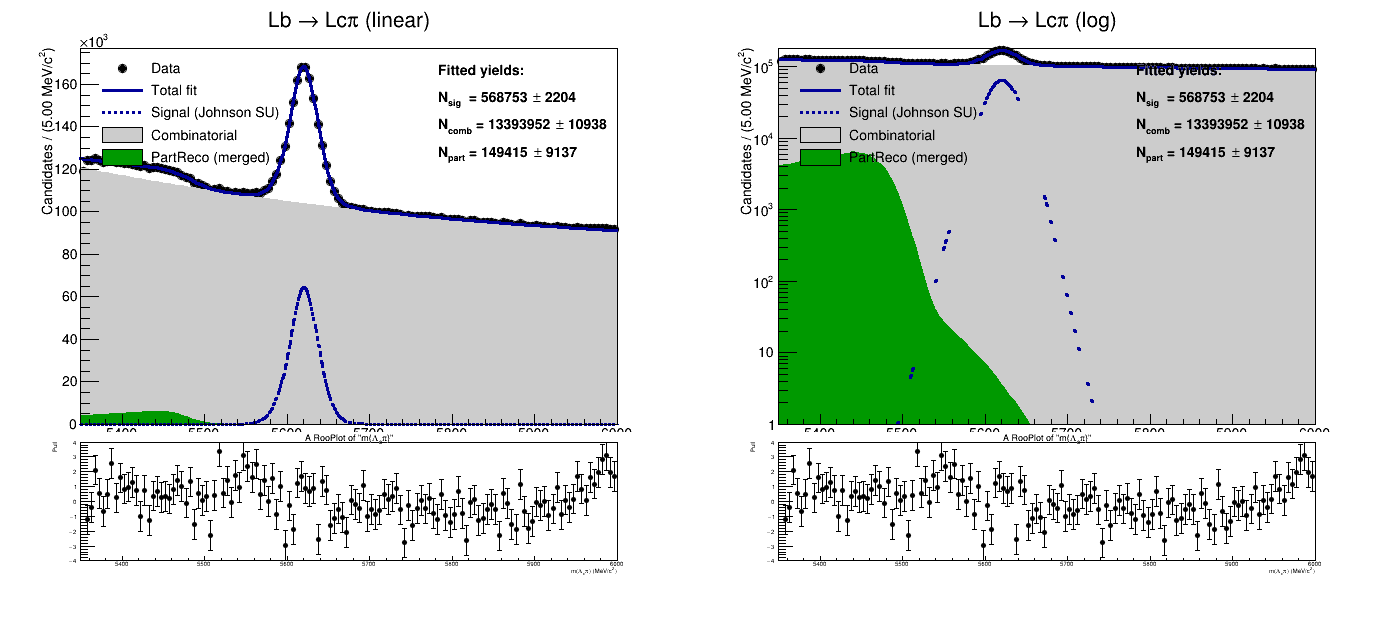

In [4]:
"""
Lb -> Lc pi binned fit (single combined sample, no simultaneous yet)
Mass range: 5350–6000 MeV

MODEL:
  - Signal: RooJohnsonSU (YOUR compiled PDF)
      RooJohnsonSU(name,title, x, mean, width, nu, tau)
    nu,tau fixed to MC anchors (edit the numbers if your Sec 6.2 differs)
  - Comb: RooProdPdf( Exponential, Chebychev(2) )
  - PartReco: merged RooHORNSdini, float sigmaPartReco

STAGED FIT:
  A) sig+comb in signal window (5565–5685) to seed mean/width
  B1) comb-only in high sideband (5800–6000) to determine comb shape
      -> build Gaussian constraint PDFs on (k,p1,p2)
  B2) (comb+part) in low sideband (5350–5565) with ExternalConstraints
  C) full fit with ExternalConstraints (comb not frozen)

PLOTS:
  - linear + pulls
  - log + pulls
  - filled components + legend + yield box
"""

# Load JohnsonSU plugin
# Inputs
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]
TREENAME = "Tuple/DecayTree"
MASSBR   = "lab0_MASS"

MASS_LO, MASS_HI = 5350.0, 6000.0
NBINS = 130

SIGW_LO, SIGW_HI     = 5565.0, 5685.0
LOW_SB_LO, LOW_SB_HI = 5350.0, 5565.0
HIGH_SB_LO, HIGH_SB_HI = 5800.0, 6000.0

OUTPDF  = "Lb2LcPi_fit_5350_6000_Johnson_correctStages.pdf"
OUTROOT = "Lb2LcPi_fit_5350_6000_Johnson_correctStages.root"

KEEP = []
HornsCls, HORNS_NAME = require_pdf_class(
    ["RooHORNSdini", "RooHornsDini", "RooHORNSDini"],
    "Need RooHORNSdini"
)
print(f"[INFO] HORNS: {HORNS_NAME}")

# Read & histogram
mass_list = []
for path in FILES:
    with uproot.open(path) as f:
        t = f[TREENAME]
        mm = t.arrays([MASSBR], library="np")[MASSBR].astype(np.float64)
        mass_list.append(mm)

mass_all = np.concatenate(mass_list)
mass_all = mass_all[(mass_all > MASS_LO) & (mass_all < MASS_HI)]
Ntot = len(mass_all)
print(f"[INFO] Entries in window: {Ntot}")

edges = np.linspace(MASS_LO, MASS_HI, NBINS + 1)
counts, _ = np.histogram(mass_all, bins=edges)

h = ROOT.TH1D("h_data", "h_data", NBINS, MASS_LO, MASS_HI)
for i in range(NBINS):
    cbin = float(counts[i])
    h.SetBinContent(i + 1, cbin)
    h.SetBinError(i + 1, np.sqrt(cbin) if cbin > 0 else 1.0)

m = ROOT.RooRealVar("BeautyMass", "m(#Lambda_{c}#pi)", MASS_LO, MASS_HI, "MeV/c^{2}")
m.setBins(NBINS)
data_hist = ROOT.RooDataHist("data_hist", "data_hist", ROOT.RooArgList(m), h)
binw = (MASS_HI - MASS_LO) / NBINS

m.setRange("sigW", SIGW_LO, SIGW_HI)
m.setRange("lowSB", LOW_SB_LO, LOW_SB_HI)
m.setRange("highSB", HIGH_SB_LO, HIGH_SB_HI)

# Signal: JohnsonSU (nu,tau fixed to MC anchors)
mean  = ROOT.RooRealVar("mean",  "mean",  5619.0, 5600.0, 5640.0)
width = ROOT.RooRealVar("width", "width", 13.2,    8.0,    25.0)

nu    = ROOT.RooRealVar("nu",  "nu",  -0.176)
tau   = ROOT.RooRealVar("tau", "tau",  0.3709)
nu.setConstant(True)
tau.setConstant(True)

sig_pdf = ROOT.RooJohnsonSU("sig", "signal JohnsonSU", m, mean, width, nu, tau)

# sanity check (helps catch NaN/inf early)
m.setVal(5619.0)
print("[INFO] JohnsonSU test getVal @5619 =", sig_pdf.getVal(ROOT.RooArgSet(m)))

# Comb: exp * cheb2
k  = ROOT.RooRealVar("k",  "k",  -0.002, -0.05, 0.0)
p1 = ROOT.RooRealVar("p1", "p1",  0.0,   -1.0, 1.0)
p2 = ROOT.RooRealVar("p2", "p2",  0.0,   -1.0, 1.0)

exp_pdf  = ROOT.RooExponential("exp", "exp", m, k)
cheb_pdf = ROOT.RooChebychev("cheb", "cheb2", m, ROOT.RooArgList(p1, p2))
comb_pdf = ROOT.RooProdPdf("comb", "comb=exp*cheb", ROOT.RooArgList(exp_pdf, cheb_pdf))

# PartReco: merged HORNS
horn_a   = ROOT.RooRealVar("horn_a",   "a",   4500.0); horn_a.setConstant(True)
horn_b   = ROOT.RooRealVar("horn_b",   "b",   5480.60); horn_b.setConstant(True)
horn_csi = ROOT.RooRealVar("horn_csi", "csi", 1.0);    horn_csi.setConstant(True)
shift_part = ROOT.RooRealVar("shift_part", "shift", 0.0); shift_part.setConstant(True)

sigmaPartReco = ROOT.RooRealVar("sigmaPartReco", "sigmaPartReco", 13.5, 8.0, 22.0)

ratio_sigma = ROOT.RooRealVar("ratio_sigma", "ratio_sigma", 3.49);   ratio_sigma.setConstant(True)
frac_sigma  = ROOT.RooRealVar("frac_sigma",  "frac_sigma",  0.9743); frac_sigma.setConstant(True)

part_pdf = HornsCls(
    "part", "merged partReco", m,
    horn_a, horn_b, horn_csi,
    shift_part, sigmaPartReco,
    ratio_sigma, frac_sigma
)

# Extended yields
Nsig  = ROOT.RooRealVar("Nsig",  "Nsig",  0.07*Ntot, 0.0, 2.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb", "Ncomb", 0.85*Ntot, 0.0, 2.0*Ntot)
Npart = ROOT.RooRealVar("Npart", "Npart", 0.08*Ntot, 0.0, 2.0*Ntot)

model = ROOT.RooAddPdf(
    "model", "total model",
    ROOT.RooArgList(sig_pdf, comb_pdf, part_pdf),
    ROOT.RooArgList(Nsig, Ncomb, Npart)
)

# Stage A: sig+comb prefit in peak window
print("\n[INFO] Stage A: sig+comb prefit in signal window")
modelA = ROOT.RooAddPdf(
    "modelA", "sig+comb",
    ROOT.RooArgList(sig_pdf, comb_pdf),
    ROOT.RooArgList(Nsig, Ncomb)
)
modelA.fitTo(
    data_hist,
    ROOT.RooFit.Range("sigW"),
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(False),
    ROOT.RooFit.Minos(False),
    ROOT.RooFit.PrintLevel(-1),
)
print(f"[INFO] Stage A: mean={mean.getVal():.3f}, width={width.getVal():.3f}")

# Stage B1: comb-only in HIGH sideband -> build Gaussian constraints
print("\n[INFO] Stage B1: comb-only in high sideband (5800–6000)")
mean.setConstant(True)
width.setConstant(True)

resB1 = comb_pdf.fitTo(
    data_hist,
    ROOT.RooFit.Range("highSB"),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
    ROOT.RooFit.Minos(False),
    ROOT.RooFit.PrintLevel(-1),
)

k0, p10, p20 = k.getVal(), p1.getVal(), p2.getVal()
ek0, ep10, ep20 = k.getError(), p1.getError(), p2.getError()
print(f"[INFO] Stage B1: k={k0:.6g}±{ek0:.2g}, p1={p10:.4g}±{ep10:.2g}, p2={p20:.4g}±{ep20:.2g}")

# floors so constraints aren't absurdly tight
k_err_floor  = 5e-5
p_err_floor  = 0.02

k_mean  = ROOT.RooConstVar("k_mean",  "k_mean",  k0)
p1_mean = ROOT.RooConstVar("p1_mean", "p1_mean", p10)
p2_mean = ROOT.RooConstVar("p2_mean", "p2_mean", p20)

k_sig  = ROOT.RooConstVar("k_sig",  "k_sig",  max(ek0,  k_err_floor))
p1_sig = ROOT.RooConstVar("p1_sig", "p1_sig", max(ep10, p_err_floor))
p2_sig = ROOT.RooConstVar("p2_sig", "p2_sig", max(ep20, p_err_floor))

c_k  = ROOT.RooGaussian("c_k",  "c_k",  k,  k_mean,  k_sig)
c_p1 = ROOT.RooGaussian("c_p1", "c_p1", p1, p1_mean, p1_sig)
c_p2 = ROOT.RooGaussian("c_p2", "c_p2", p2, p2_mean, p2_sig)

ext_constraints = ROOT.RooArgSet(c_k, c_p1, c_p2)

# Stage B2: low-sideband fit for PartReco with comb constrained
print("\n[INFO] Stage B2: comb+part in low sideband (5350–5565), signal off")
Nsig.setVal(0.0)
Nsig.setConstant(True)

modelB2 = ROOT.RooAddPdf(
    "modelB2", "comb+part",
    ROOT.RooArgList(comb_pdf, part_pdf),
    ROOT.RooArgList(Ncomb, Npart)
)

resB2 = modelB2.fitTo(
    data_hist,
    ROOT.RooFit.Range("lowSB"),
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.ExternalConstraints(ext_constraints),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
    ROOT.RooFit.Minos(False),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.PrintLevel(-1),
)
print(f"[INFO] Stage B2: Npart={Npart.getVal():.0f} ± {Npart.getError():.0f}, "
      f"sigmaPartReco={sigmaPartReco.getVal():.3f} ± {sigmaPartReco.getError():.3f}")

# Stage C: full fit with external constraints (comb not frozen)
print("\n[INFO] Stage C: full fit")
Nsig.setConstant(False)
mean.setConstant(False)
width.setConstant(False)

fitres = model.fitTo(
    data_hist,
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.ExternalConstraints(ext_constraints),
    ROOT.RooFit.Strategy(1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Hesse(True),
    ROOT.RooFit.Minos(False),
)
fitres.Print("v")

print("\n=== FITTED YIELDS ===")
print(f"Nsig   = {Nsig.getVal():.0f} ± {Nsig.getError():.0f}")
print(f"Ncomb  = {Ncomb.getVal():.0f} ± {Ncomb.getError():.0f}")
print(f"Npart  = {Npart.getVal():.0f} ± {Npart.getError():.0f}")

print("\n=== SIGNAL (JohnsonSU) ===")
print(f"mean  = {mean.getVal():.3f} ± {mean.getError():.3f}")
print(f"width = {width.getVal():.3f} ± {width.getError():.3f}")
print(f"nu (fixed)  = {nu.getVal():.4f}")
print(f"tau (fixed) = {tau.getVal():.4f}")

print("\n=== PARTRECO ===")
print(f"sigmaPartReco = {sigmaPartReco.getVal():.3f} ± {sigmaPartReco.getError():.3f}")

# Plotting (filled components + pulls)
COL_COMB = ROOT.kGray
COL_PART = ROOT.kGreen + 2
COL_TOT  = ROOT.kBlue + 2
COL_SIG  = ROOT.kBlue + 2
def draw_frame_constrained(title, logy=False):
    frame = m.frame(ROOT.RooFit.Title(title))
    data_hist.plotOn(frame, ROOT.RooFit.Name("data"), ROOT.RooFit.DataError(ROOT.RooAbsData.SumW2))

    # without forcing Normalization() (RooFit uses extended normalization).
    model.plotOn(frame, ROOT.RooFit.Components("comb"),
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_COMB))
    model.plotOn(frame, ROOT.RooFit.Components("part"),
                 ROOT.RooFit.DrawOption("F"),
                 ROOT.RooFit.FillStyle(1001),
                 ROOT.RooFit.FillColor(COL_PART))

    model.plotOn(frame, ROOT.RooFit.Name("model"),
                 ROOT.RooFit.LineColor(COL_TOT),
                 ROOT.RooFit.LineWidth(3))
    model.plotOn(frame, ROOT.RooFit.Components("sig"),
                 ROOT.RooFit.LineColor(COL_SIG),
                 ROOT.RooFit.LineStyle(ROOT.kDashed),
                 ROOT.RooFit.LineWidth(3))

    frame.SetYTitle(f"Candidates / ({binw:.2f} MeV/c^{{2}})")
    if logy:
        frame.SetMinimum(1.0)
    return frame
cmain = ROOT.TCanvas("cmain", "cmain", 1400, 650)
cmain.Divide(2, 1)
KEEP.append(cmain)
build_column(1, "Lb #rightarrow Lc#pi (linear)", logy=False)
build_column(2, "Lb #rightarrow Lc#pi (log)",    logy=True)

cmain.SaveAs(OUTPDF)
print(f"\n[INFO] Saved plot: {OUTPDF}")

# Workspace
ws = ROOT.RooWorkspace("ws")
getattr(ws, "import")(data_hist)
getattr(ws, "import")(model)
getattr(ws, "import")(fitres)
fout = ROOT.TFile(OUTROOT, "RECREATE")
ws.Write()
fout.Close()
print(f"[INFO] Saved workspace: {OUTROOT}")


=== Auto-identification ===
lab1 median MASS = 139.57 MeV
lab2 median MASS = 2290.25 MeV
lab3 median MASS = 938.27 MeV

Chosen Λc candidate: lab2
Chosen bachelor:     lab1

=== Switched-mass visibility: m(LcK) ===
Signal window: 5594.6 .. 5644.6 MeV
Sidebands:     5544.6..5584.6 and 5654.6..5694.6 MeV
Sobs (in window)        = 1116843
Bexp (sideband scaled)  = 1214598.8
Sexcess (Sobs-Bexp)     = -97755.8
Z ~ Sexcess/sqrt(S+B)   = -64.02
[VERDICT] Probably not visible enough to constrain from data (Z < 2).

[INFO] Saved plot: switched_mass_LcK_check.png



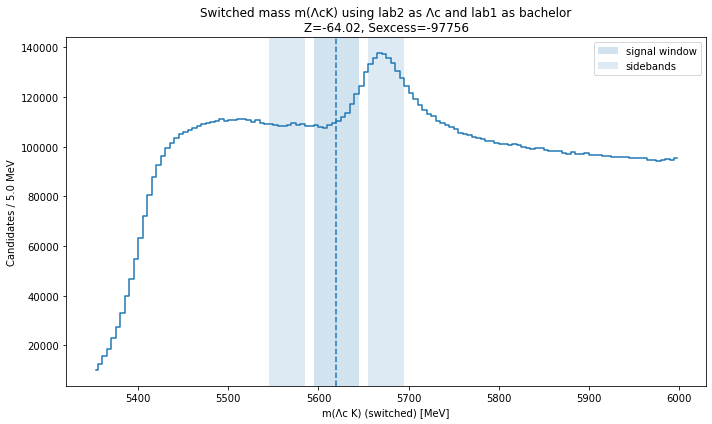

In [10]:
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]
TREENAME = "Tuple/DecayTree"

# Physics masses (MeV)
M_LC = 2286.46
M_K  = 493.677

# Windows for visibility test in switched mass
LB_MASS = 5619.6
WIN = 25.0
SB_GAP = 10.0
SB_W = 40.0

# Histogram range for plotting
MLO, MHI = 5350.0, 6000.0
NBINS = 130

def read_concat(branches):
    out = {b: [] for b in branches}
    for path in FILES:
        with uproot.open(path) as f:
            t = f[TREENAME]
            arr = t.arrays(branches, library="np")
            for b in branches:
                out[b].append(arr[b].astype(np.float64))
    return {b: np.concatenate(out[b]) for b in branches}

def p2(px,py,pz):
    return px*px + py*py + pz*pz

def mass_from(E,px,py,pz):
    m2 = E*E - p2(px,py,pz)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)

def visibility(m):
    m = m[np.isfinite(m)]
    m = m[(m > MLO) & (m < MHI)]
    sig_lo, sig_hi = LB_MASS - WIN, LB_MASS + WIN
    Sobs = np.sum((m >= sig_lo) & (m < sig_hi))

    left_lo  = LB_MASS - (WIN + SB_GAP + SB_W)
    left_hi  = LB_MASS - (WIN + SB_GAP)
    right_lo = LB_MASS + (WIN + SB_GAP)
    right_hi = LB_MASS + (WIN + SB_GAP + SB_W)

    Bleft  = np.sum((m >= left_lo) & (m < left_hi))
    Bright = np.sum((m >= right_lo) & (m < right_hi))

    w_sig = sig_hi - sig_lo
    w_sb  = (left_hi - left_lo) + (right_hi - right_lo)
    Bexp = (Bleft + Bright) * (w_sig / w_sb) if w_sb > 0 else 0.0

    Sexcess = Sobs - Bexp
    Z = Sexcess / np.sqrt(max(Sobs + Bexp, 1.0))
    return Sobs, Bexp, Sexcess, Z, (sig_lo,sig_hi), ((left_lo,left_hi),(right_lo,right_hi))

def main():
    # We will use lab1, lab2, lab3 candidates and identify which is Λc by mass ~2286
    branches = [
        "lab0_MASS",
        "lab1_MASS","lab1_PX","lab1_PY","lab1_PZ",
        "lab2_MASS","lab2_PX","lab2_PY","lab2_PZ",
        "lab3_MASS","lab3_PX","lab3_PY","lab3_PZ",
    ]
    a = read_concat(branches)

    # Identify Λc candidate by which labX_MASS is closest to 2286 (in median)
    labs = ["lab1","lab2","lab3"]
    med = {lab: np.nanmedian(a[f"{lab}_MASS"]) for lab in labs}
    closest = sorted(labs, key=lambda lab: abs(med[lab]-M_LC))
    lc_lab = closest[0]

    # bachelor is whichever remaining lab has *smallest* median mass (usually track mass assignment)
    remaining = [lab for lab in labs if lab != lc_lab]
    med_rem = {lab: med[lab] for lab in remaining}
    bach_lab = sorted(remaining, key=lambda lab: med_rem[lab])[0]

    print("\n=== Auto-identification ===")
    for lab in labs:
        print(f"{lab} median MASS = {med[lab]:.2f} MeV")
    print(f"\nChosen Λc candidate: {lc_lab}")
    print(f"Chosen bachelor:     {bach_lab}")

    lc_px, lc_py, lc_pz = a[f"{lc_lab}_PX"], a[f"{lc_lab}_PY"], a[f"{lc_lab}_PZ"]
    b_px,  b_py,  b_pz  = a[f"{bach_lab}_PX"], a[f"{bach_lab}_PY"], a[f"{bach_lab}_PZ"]

    E_lc = np.sqrt(p2(lc_px,lc_py,lc_pz) + M_LC*M_LC)
    E_k  = np.sqrt(p2(b_px,b_py,b_pz) + M_K*M_K)

    E = E_lc + E_k
    px = lc_px + b_px
    py = lc_py + b_py
    pz = lc_pz + b_pz

    m_sw = mass_from(E,px,py,pz)

    # Visibility test
    Sobs, Bexp, Sexcess, Z, sigW, sbW = visibility(m_sw)
    print("\n=== Switched-mass visibility: m(LcK) ===")
    print(f"Signal window: {sigW[0]:.1f} .. {sigW[1]:.1f} MeV")
    print(f"Sidebands:     {sbW[0][0]:.1f}..{sbW[0][1]:.1f} and {sbW[1][0]:.1f}..{sbW[1][1]:.1f} MeV")
    print(f"Sobs (in window)        = {Sobs:.0f}")
    print(f"Bexp (sideband scaled)  = {Bexp:.1f}")
    print(f"Sexcess (Sobs-Bexp)     = {Sexcess:.1f}")
    print(f"Z ~ Sexcess/sqrt(S+B)   = {Z:.2f}")

    if Z >= 5:
        print("[VERDICT] Very likely visible (Z >= 5).")
    elif Z >= 3:
        print("[VERDICT] Likely visible (3 <= Z < 5).")
    elif Z >= 2:
        print("[VERDICT] Marginal (2 <= Z < 3).")
    else:
        print("[VERDICT] Probably not visible enough to constrain from data (Z < 2).")

    # Save a quick plot for inspection
    hist, edges = np.histogram(m_sw[(m_sw>MLO)&(m_sw<MHI)], bins=NBINS, range=(MLO,MHI))
    centers = 0.5*(edges[1:]+edges[:-1])

    plt.figure(figsize=(10,6))
    plt.step(centers, hist, where="mid")
    plt.axvline(LB_MASS, linestyle="--")
    plt.axvspan(sigW[0], sigW[1], alpha=0.2, label="signal window")
    plt.axvspan(sbW[0][0], sbW[0][1], alpha=0.15, label="sidebands")
    plt.axvspan(sbW[1][0], sbW[1][1], alpha=0.15)
    plt.xlabel("m(Λc K) (switched) [MeV]")
    plt.ylabel(f"Candidates / {(MHI-MLO)/NBINS:.1f} MeV")
    plt.title(f"Switched mass m(ΛcK) using {lc_lab} as Λc and {bach_lab} as bachelor\nZ={Z:.2f}, Sexcess={Sexcess:.0f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("switched_mass_LcK_check.png", dpi=150)
    print("\n[INFO] Saved plot: switched_mass_LcK_check.png")

if __name__ == "__main__":
    main()